# 03. 도로타입 / 도로번호 / 지역 기반 돌발 패턴 분석

**참고**: `지역` 컬럼은 원본 전처리에 포함되어 있지 않은 파생 컬럼입니다. 위경도(X, Y) 좌표를 실제 시/도 행정경계(통계청 SGIS 기반, `src/region_mapping.py`)에 point-in-polygon 방식으로 매칭해 분류했습니다. 행정경계 밖으로 판정되는 좌표(해상/GPS 오차 등, 약 0.3%)는 가장 가까운 시/도로 대체 배정했습니다.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import load
from src.plot_config import set_korean_style

set_korean_style()
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load()
df.shape

(623188, 19)

## 3.1 도로타입별 돌발 건수

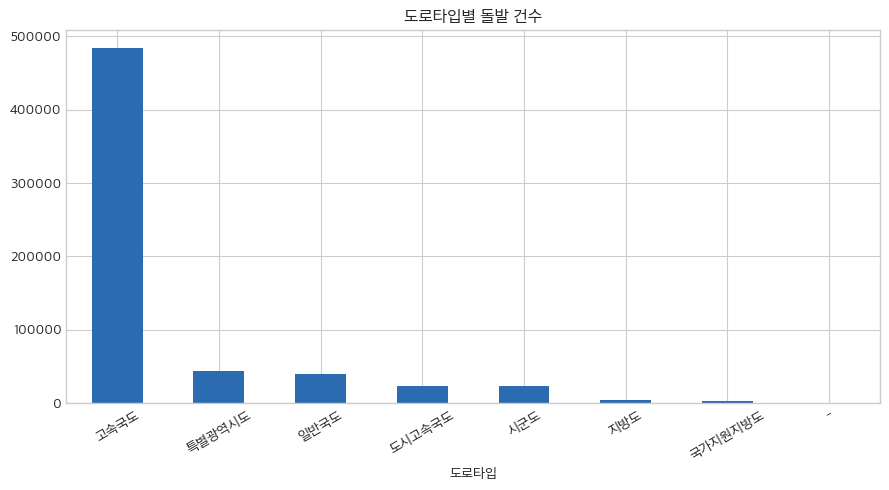

In [2]:
road_type_cnt = df['도로타입'].value_counts()
fig, ax = plt.subplots(figsize=(9,5))
road_type_cnt.plot(kind='bar', ax=ax, color='#2b6cb0')
ax.set_title('도로타입별 돌발 건수')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_road_type_count.png', dpi=150)
plt.show()

## 3.2 도로타입별 돌발구분 구성비

돌발구분,공사,교통사고,기상,기타,기타돌발,재난
도로타입,,,,,,
-,61.28,29.77,0.93,8.02,0.00,0.00
고속국도,25.22,19.98,7.53,1.18,43.42,2.67
국가지원지방도,62.25,29.72,0.59,7.44,0.00,0.00
도시고속국도,22.72,75.99,0.58,0.70,0.00,0.00
시군도,76.41,17.70,1.22,4.67,0.00,0.00
일반국도,63.85,25.84,0.78,2.84,6.44,0.25
지방도,75.11,19.80,3.51,1.58,0.00,0.00
특별광역시도,56.01,34.45,0.74,8.79,0.00,0.00


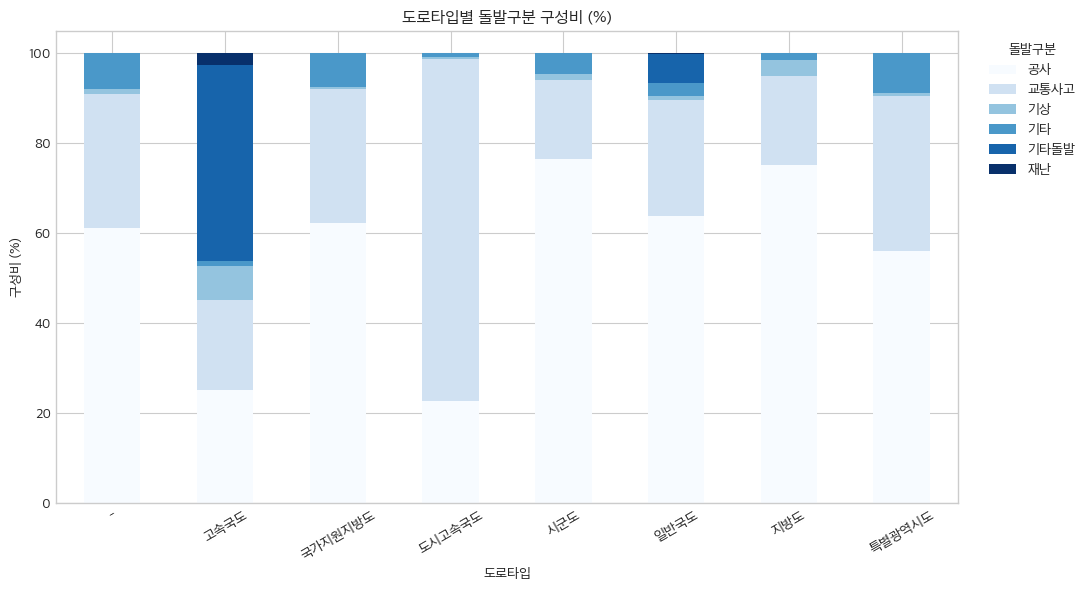

In [3]:
comp = pd.crosstab(df['도로타입'], df['돌발구분'], normalize='index') * 100
comp = comp.round(2)
display(comp)

fig, ax = plt.subplots(figsize=(11,6))
comp.plot(kind='bar', stacked=True, ax=ax, colormap='Blues')
ax.set_title('도로타입별 돌발구분 구성비 (%)')
ax.set_ylabel('구성비 (%)')
plt.xticks(rotation=30)
ax.legend(title='돌발구분', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_road_type_composition.png', dpi=150)
plt.show()

## 3.3 도로번호별 돌발 비율 (Top, 2% 이상만 표시)

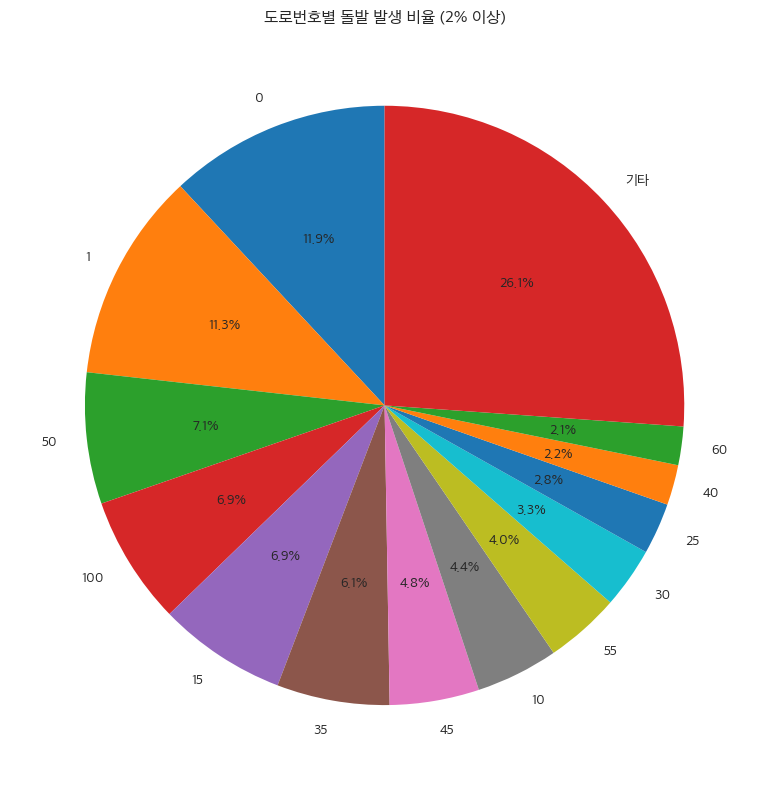

In [4]:
road_num = df['도로번호'].dropna().astype(int).astype(str)
pct = road_num.value_counts(normalize=True) * 100
top_roads = pct[pct >= 2]
etc = pd.Series({'기타': pct[pct < 2].sum()})
pie_data = pd.concat([top_roads, etc])

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
ax.set_title('도로번호별 돌발 발생 비율 (2% 이상)')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_road_number_pie.png', dpi=150)
plt.show()

## 3.4 시/도별 돌발 횟수 (행정경계 기준)

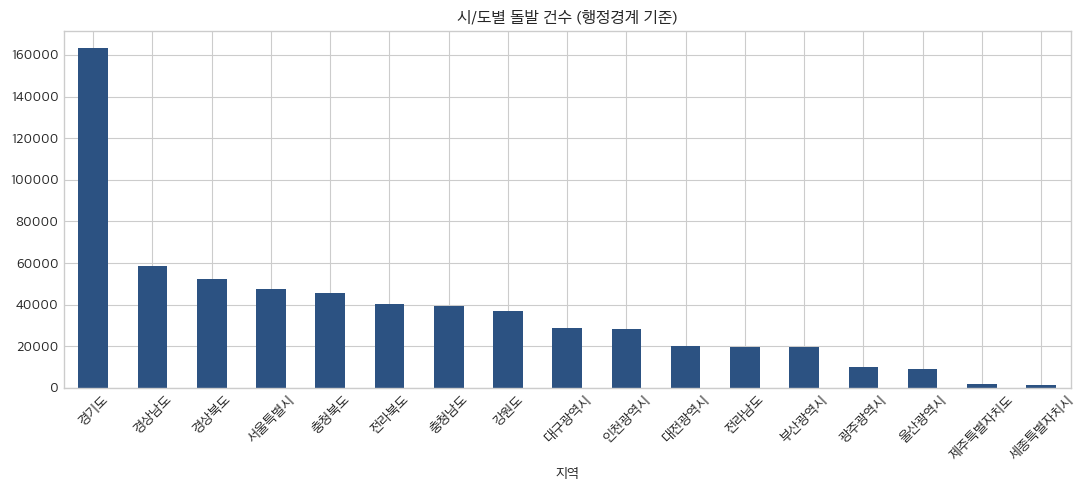

In [5]:
from src.region_mapping import assign_region
df['지역'] = assign_region(df['Y'], df['X'])

region_cnt = df['지역'].value_counts()
fig, ax = plt.subplots(figsize=(11,5))
region_cnt.plot(kind='bar', ax=ax, color='#2c5282')
ax.set_title('시/도별 돌발 건수 (행정경계 기준)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / '10_region_count.png', dpi=150)
plt.show()

## 3.5 시/도별 Top1 돌발유형

In [6]:
region_type = pd.crosstab(df['지역'], df['돌발구분'], normalize='index') * 100
region_top1 = region_type.idxmax(axis=1)
pd.DataFrame({'Top1 돌발구분': region_top1}).sort_index()

,Top1 돌발구분
지역,
강원도,공사
경기도,기타돌발
경상남도,기타돌발
경상북도,기타돌발
광주광역시,공사
대구광역시,공사
대전광역시,공사
부산광역시,공사
서울특별시,교통사고
